# Gaussian KL flows on covariance matrices

For centered Gaussians, the entropy force is affine:
$g(x)=(\bar\Sigma^{-1}-\Sigma^{-1})x$. The toolbox evaluates the
covariance ODE with a square-root factor, without inverting the
force covariance. The state covariance must remain positive definite.

We use SciPy's adaptive ODE solver for a short interval and check
positivity and decay at sampled times. These checks do not certify
global existence or positivity between samples.

This first example uses isotropic covariances, avoiding nonsmooth
force-rank changes. Here $\Sigma_t=s(t)I$ and the exact equation is
$s'=-2d^{1-1/p}(s-1)$. Different rates along this particular path
do not imply different optimal Gaussian Poincare constants.

Run from an environment with `pip install -e '.[notebooks,transport]'` from
the repository root. In Colab, first run
`%pip install 'muon-dynamics[notebooks,transport] @ git+https://github.com/gpeyre/muon-dynamics.git'`.
All particle arrays have particles in rows. No training data are downloaded.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import muon_dynamics as md

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

from scipy.integrate import solve_ivp


Matplotlib is building the font cache; this may take a moment.


In [2]:
initial = 2*np.eye(2)
target = np.eye(2)
times = np.linspace(0, 1.5, 90)
solutions = {}
for p in [1, 2, np.inf]:
    def rhs(t, flat):
        S = flat.reshape(2, 2)
        return md.gaussian_kl_rhs((S+S.T)/2, target, p).ravel()
    sol = solve_ivp(rhs, (0, times[-1]), initial.ravel(), t_eval=times,
                    rtol=1e-7, atol=1e-9, max_step=.02)
    assert sol.success, sol.message
    covariances = sol.y.T.reshape(-1, 2, 2)
    assert np.linalg.eigvalsh(covariances).min() > 0
    energy = np.array([md.gaussian_kl(S, target) for S in covariances])
    assert np.max(np.diff(energy)) < 1e-7
    rate = 2 * 2**(1 - (0 if np.isinf(p) else 1/p))
    np.testing.assert_allclose(covariances[:, 0, 0], 1+np.exp(-rate*times), atol=2e-7)
    solutions[p] = covariances, energy


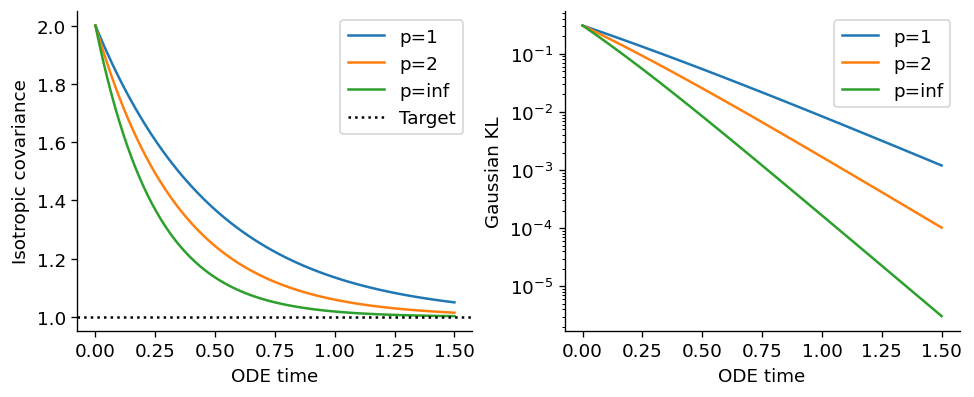

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), constrained_layout=True)
for p, (covariances, energy) in solutions.items():
    axes[0].plot(times, covariances[:, 0, 0], label=f"p={p:g}")
    axes[1].semilogy(times, energy, label=f"p={p:g}")
axes[0].axhline(1, linestyle=":", color="black", label="Target")
axes[0].set(xlabel="ODE time", ylabel="Isotropic covariance")
axes[1].set(xlabel="ODE time", ylabel="Gaussian KL")
axes[0].legend()
axes[1].legend()
fig.savefig("04_gaussian_kl.png", dpi=130)
plt.show()
